## General stuff
Guassian:\
$\phi(x) = e^{-\|x\|^2}$

Image function:\
$ f : \mathbb{R}^2 \to \mathbb{R}$

Approximation:\
$ \hat{f}(x) = \sum^n_{i=0}\alpha_i (g_i \triangleright \phi)(y) = \sum^n_{i=0}\alpha_i (\psi(v_i) \triangleright \phi)(y)$

Lie group (dim 6):\
$G = \text{Aff}^+(2)$

Group action on $R^2$:\
For $g \in G, y \in R^2$ then $g \triangleright y = (x, A) \triangleright y := Ay + x$

For $f : \mathbb{R}^2 \to \mathbb{R}$ then $(g \triangleright f)(y) := f(g^{-1} \triangleright y)$ 

Parameter space (dim 6):\
$V = \mathbb{R}^2 \times \text{SO}(2) \times \text{SNM}(2)$

Mapping:\
$\psi : V \to G$\
$\psi(L, X, Y) = (L, \exp(X)\exp(Y))$

For $X = \begin{pmatrix}
0 & b \\
-b & 0
\end{pmatrix}$ then $\exp(X) = \begin{pmatrix}
\cos(b) & \sin(b) \\
-\sin(b) & \cos(b)
\end{pmatrix}$

For
$
Y=\begin{pmatrix}a & b \\ b & c\end{pmatrix},
$
define
$
m=\tfrac{a+c}{2}, \quad 
B = Y - mI = \begin{pmatrix}\tfrac{a-c}{2} & b \\[4pt] b & -\tfrac{a-c}{2}\end{pmatrix}, \quad 
s=\sqrt{b^{2}+\left(\tfrac{a-c}{2}\right)^{2}}.
$

Then
$
\exp(Y) \;=\; e^{\,m}\!\left( \cosh(s)\,I + \frac{\sinh(s)}{s}\,B \right).
$

Loss:\
$\mathcal{L} = \|f-\hat{f}\|_{L^2}$

In [1]:
import torch
import numpy as np
import math
from pytorch_msssim import SSIM

In [2]:
# Mapping from parametric space to lie group

# Map exp of the theta of a 2x2 anti symmetric matrix to explicit
def exp_SO(theta: torch.Tensor) -> torch.Tensor:
    return torch.stack([torch.stack([torch.cos(theta), -torch.sin(theta)]),
                         torch.stack([torch.sin(theta), torch.cos(theta)])]).permute(2, 0, 1)

# Map exp of 2x2 symmetric matrix to explicit
def exp_SNM(a: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
    m = torch.stack([
        torch.stack([torch.exp(a), torch.zeros_like(c)]),
        torch.stack([torch.zeros_like(a), torch.exp(c)])
    ]).permute(2, 0, 1)

    return m




In [3]:
# gaussian

def gaussian(y: torch.Tensor):
    norm = torch.linalg.vector_norm(y, dim=-1)
    return torch.exp(-1 * torch.pow(norm, 2))

def f_hat(w: torch.Tensor, width: int, height: int, normalize_only_alpha: bool) -> torch.Tensor:
    """
    Calculate f_hat with w for the grid width to height
    """
    # calc all parameters
    red = w[0]
    green = w[1]
    blue = w[2]

    color = torch.stack([red, green, blue]).permute(1, 0)

    a = w[3]
    c = w[4]
    theta = w[5]
    x1 = w[6]
    x2 = w[7]

    Y = exp_SNM(a, c)

    A = exp_SO(theta) @ Y
    x = torch.stack([x1, x2]).permute(1, 0)
    sampling_grid = torch.nn.functional.affine_grid(
        torch.cat([torch.linalg.inv(A), (torch.linalg.inv(A) @ (x*-1).unsqueeze(-1))], dim=-1), 
        torch.Size((A.size()[0], 1, height, width)))

    norm = torch.linalg.vector_norm(sampling_grid, dim=-1)
    gaussian_values = torch.exp(-1 * torch.pow(norm, 2))

    if normalize_only_alpha:
        return (torch.einsum('gjk,gd->gdjk', gaussian_values, color.abs())).sum(dim=0)
        # return (torch.sigmoid(alpha.abs()).unsqueeze(-1).unsqueeze(-1) * torch.exp(-1 * torch.pow(norm, 2))).sum(dim=0)
    # else:
    #     return torch.sigmoid((alpha.unsqueeze(-1).unsqueeze(-1) * torch.exp(-1 * torch.pow(norm, 2))).sum(dim=0))



In [4]:

torch.autograd.set_detect_anomaly(False)

device = torch.device("cuda:0")

def train(learning_rate: float, iterations: int, guassians: int, target: torch.Tensor, normalize_only_alpha: bool):

    ssim_module = SSIM(data_range=1, size_average=True, channel=3)
    lambda_ = 0.9

    w_start = torch.randn(8, guassians, device=device)

    w_start[3] -= 4
    w_start[4] -= 4

    w = torch.nn.Parameter(w_start)
    
    # w[0] = red
    # w[1] = green
    # w[2] = blue
    # w[3] = a
    # w[4] = c
    # w[5] = theta
    # w[6] = x1
    # w[7] = x2

    optimizer = torch.optim.AdamW(
        [w],
        lr=learning_rate,
        betas=(0.5, 0.9),
    )
    scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=iterations)

    for iteration in range(iterations):
            
        preds = f_hat(w, target.size()[1], target.size()[2], normalize_only_alpha)

        # loss = (target - preds).abs().mean()# + torch.where(w[1].abs() > w[2].abs(), (w[1].abs()/w[2].abs()), (w[2].abs()/w[1].abs())).mean() * 0.01
        ssim_loss = 1 - ssim_module(preds.unsqueeze(0), target.unsqueeze(0))
        l1_loss = (target - preds).abs().mean()
        loss = (1 - lambda_) * ssim_loss + lambda_ * l1_loss

        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        if iterations > 10 and (iteration + 1) % round(iterations/10) == 0:
            print(f"Iteration {iteration+1}/{iterations}")
            print(f"Loss: {loss.item():0.5f}")


            
    preds = f_hat(w, target.size()[1], target.size()[2], normalize_only_alpha)
    ssim_loss = 1 - ssim_module(preds.unsqueeze(0), target.unsqueeze(0))
    l1_loss = (target - preds).abs().mean()
    loss = (1 - lambda_) * ssim_loss + lambda_ * l1_loss

    return loss, w

In [5]:
import torchvision

def img_to_tensor(img_path: str) -> torch.Tensor:
    return torchvision.io.read_image(img_path)

In [6]:
import matplotlib.pyplot as plt
# plot 2D image of gaussian function
def plot_image(w: torch.Tensor, resolution, normalize_only_alpha: bool):
    w = w.detach().cpu()
    plt.title("2D Gaussian")
    plt.imshow(f_hat(w, resolution, resolution, normalize_only_alpha).permute(1, 2, 0), origin='upper', vmin=0, vmax=1)
    plt.show()

torch.Size([1, 3])
torch.Size([1, 3, 100, 100])


/var/home/victor/Code/bep/.venv/lib64/python3.13/site-packages/torch/nn/functional.py:5163: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


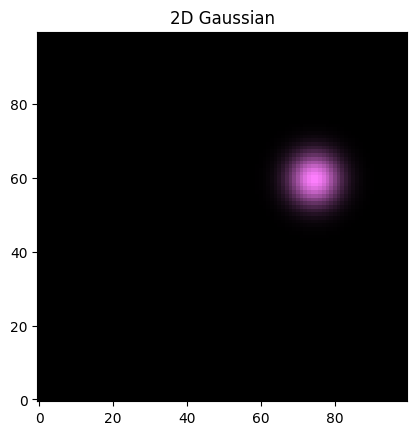

In [32]:
# w = torch.tensor([[-1,  -2, 1,  torch.pi/1.5, 0.5 - 2, 0.2 + 1], [-1,  -2, 1,  torch.pi/1.5, 0.5 - 2, 0.2 + 1]]).permute(1, 0)
w_prime = torch.tensor([[1, 0.5, 1,  -2, -2, torch.pi/1.5,  0.5, 0.2]]).permute(1, 0)

plt.title("2D Gaussian")
plt.imshow(f_hat(w_prime, 100, 100, True).permute(1, 2, 0), origin='lower', vmin=0, vmax=1)
plt.show()

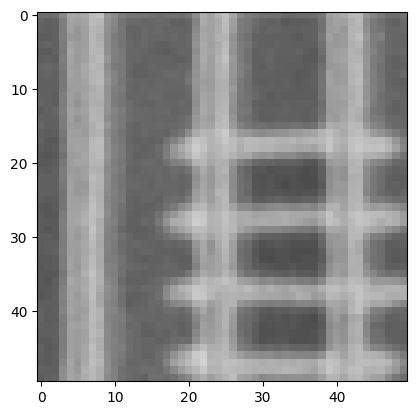

In [9]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/sem-railroad.png').float(), 0, 0, 450, 450)

plt.imshow(torchvision.transforms.Resize(50)(img).mean(0), origin='upper', cmap='gray', vmin=0, vmax=255)

In [12]:
learning_rate = 0.001
iterations = 5000
guassians = 500

output_z = torchvision.transforms.Resize(50)(img).mean(0).to(device) / 255.0
loss, w = train(learning_rate, iterations, guassians, output_z, False)

print(loss)

Iteration 500/5000
Loss: 0.11388
Iteration 1000/5000
Loss: 0.06506
Iteration 1500/5000
Loss: 0.03467
Iteration 2000/5000
Loss: 0.02907
Iteration 2500/5000
Loss: 0.02402
Iteration 3000/5000
Loss: 0.02208
Iteration 3500/5000
Loss: 0.02113
Iteration 4000/5000
Loss: 0.02030
Iteration 4500/5000
Loss: 0.02154
Iteration 5000/5000
Loss: 0.02033
tensor(0.0282, device='cuda:0', grad_fn=<MeanBackward0>)


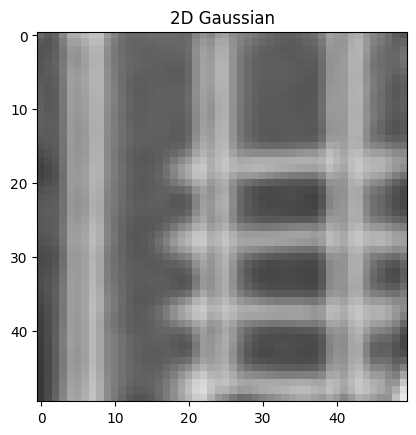

In [14]:
plot_image(w, 50, False)

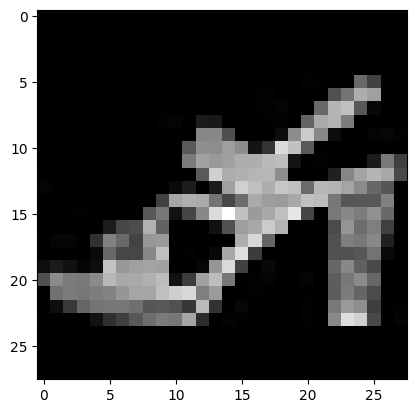

In [164]:
img = torchvision.io.decode_image('./data/fashionmnist-val-1003.png')[0]

plt.imshow(img, origin='upper', cmap='gray', vmin=0, vmax=255)
plt.show()

In [165]:

print(img.size())

learning_rate = 1e-3
iterations = 10000
guassians = 100
# create a 5x5 with a black stripe in the middle
output_z = img.to(device) / 255.0

loss, w = train(learning_rate, iterations, guassians, output_z, False)

print(loss)

torch.Size([28, 28])
Iteration 1000/10000
Loss: 0.07894
Iteration 2000/10000
Loss: 0.06571
Iteration 3000/10000
Loss: 0.06135
Iteration 4000/10000
Loss: 0.05803
Iteration 5000/10000
Loss: 0.05400
Iteration 6000/10000
Loss: 0.04942
Iteration 7000/10000
Loss: 0.04613
Iteration 8000/10000
Loss: 0.04224
Iteration 9000/10000
Loss: 0.03532
Iteration 10000/10000
Loss: 0.03356
tensor(0.0332, device='cuda:0', grad_fn=<MeanBackward0>)


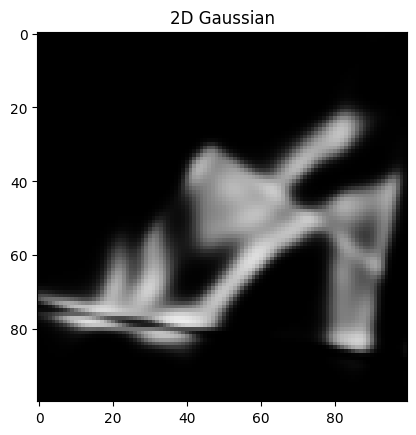

In [166]:

plot_image(w, 100, False)

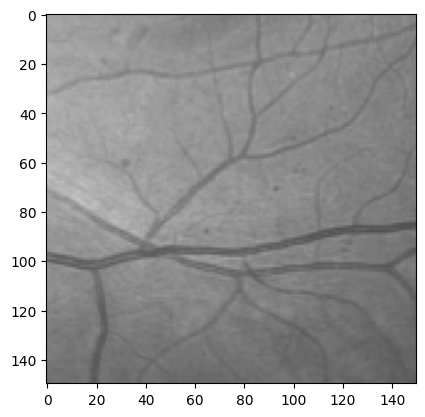

In [13]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/retinal-vessels.jpg'), 0, 0, 230, 230).float()
img = torchvision.transforms.Resize(150)(img).mean(0)

plt.imshow(img, origin='upper', cmap='gray', vmin=0, vmax=255)

In [17]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/retinal-vessels.jpg'), 0, 0, 230, 230).float()

print(img.size())

learning_rate = 1e-2
iterations = 500
guassians = 2000

# create a 5x5 with a black stripe in the middle
output_z = torchvision.transforms.Resize(150)(img).mean(0).to(device) / 255.0
print(output_z)

loss, w = train(learning_rate, iterations, guassians, output_z, False)


torch.Size([3, 230, 230])
tensor([[0.6351, 0.6404, 0.6320,  ..., 0.4916, 0.4972, 0.4879],
        [0.6477, 0.6432, 0.6318,  ..., 0.5065, 0.4931, 0.5076],
        [0.6408, 0.6395, 0.6364,  ..., 0.5126, 0.4969, 0.5263],
        ...,
        [0.4338, 0.4396, 0.4486,  ..., 0.3773, 0.3850, 0.3864],
        [0.4269, 0.4350, 0.4464,  ..., 0.3698, 0.3751, 0.3766],
        [0.4278, 0.4319, 0.4379,  ..., 0.3763, 0.3691, 0.3708]],
       device='cuda:0')
Iteration 50/500
Loss: 0.08258
Iteration 100/500
Loss: 0.05043
Iteration 150/500
Loss: 0.04134
Iteration 200/500
Loss: 0.03518
Iteration 250/500
Loss: 0.03142
Iteration 300/500
Loss: 0.03047
Iteration 350/500
Loss: 0.02886
Iteration 400/500
Loss: 0.02734
Iteration 450/500
Loss: 0.02666
Iteration 500/500
Loss: 0.02591


tensor(0.0250, device='cuda:0', grad_fn=<AddBackward0>)


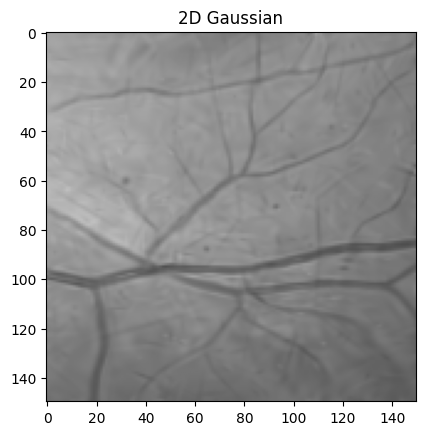

In [18]:
print(loss)
plot_image(w, 150, False)

tensor(0.1227, device='cuda:0', grad_fn=<AddBackward0>)
36


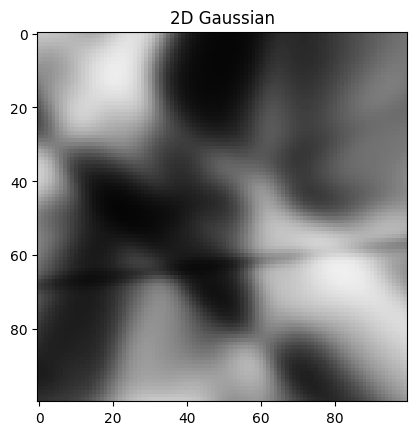

In [350]:
print(loss)
# find all w where |alpha| < 0.05 and |x1| > 1.5 and |x2| > 1.5
mask = (w[1]-w[2]).abs() > 3
# print(w[0][mask])
print(len(w[0][mask]))

plot_image(w[:, mask], 100, False)

torch.Size([3, 230, 230])
tensor(0.6579, device='cuda:0', grad_fn=<AddBackward0>)


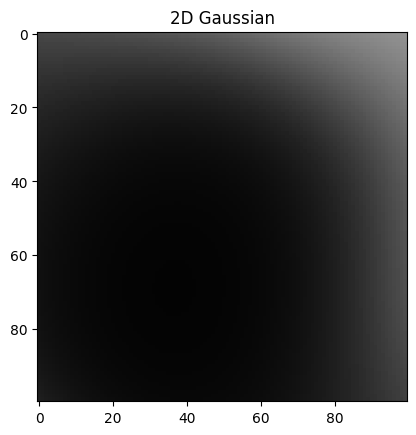

In [194]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/retinal-vessels.jpg'), 0, 0, 230, 230).float()

print(img.size())

learning_rate = 1e-3
iterations = 0
guassians = 500


# create a 5x5 with a black stripe in the middle
output_z = torchvision.transforms.Resize(75)(img).mean(0).to(device) / 255.0
loss, w = train(learning_rate, iterations, guassians, output_z, False)

print(loss)

plot_image(w, 100, False)

In [60]:
img = torchvision.io.decode_image('./data/bsd300-castle.jpg')

print(img.size())

torch.Size([3, 481, 321])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.060975224..1.0000002].


torch.Size([3, 150, 150])


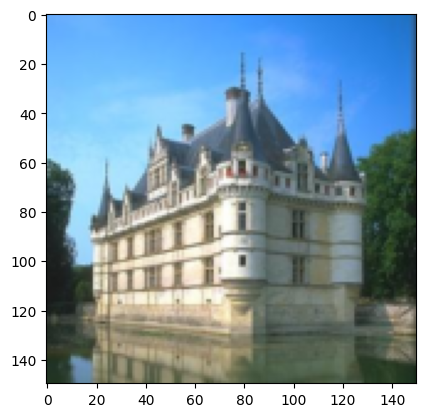

In [90]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/bsd300-castle.jpg'), 0, 0, 321, 321).float()

learning_rate = 0.01
iterations = 500
guassians = 2000

# create a 5x5 with a black stripe in the middle
output_z = torchvision.transforms.Resize(150)(img).to(device) / 255.0
plt.imshow(output_z.cpu().permute(1, 2, 0), origin='upper', vmin=0, vmax=1)

print(output_z.size())

In [91]:
loss, w = train(learning_rate, iterations, guassians, output_z, True)

print(loss)

Iteration 50/500
Loss: 0.25442
Iteration 100/500
Loss: 0.13848
Iteration 150/500
Loss: 0.08282
Iteration 200/500
Loss: 0.06172
Iteration 250/500
Loss: 0.05209
Iteration 300/500
Loss: 0.04675
Iteration 350/500
Loss: 0.04277
Iteration 400/500
Loss: 0.03972
Iteration 450/500
Loss: 0.03764
Iteration 500/500
Loss: 0.03619
tensor(0.0362, device='cuda:0', grad_fn=<AddBackward0>)


tensor(0.0362, device='cuda:0', grad_fn=<AddBackward0>)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.074298024..1.1443381].


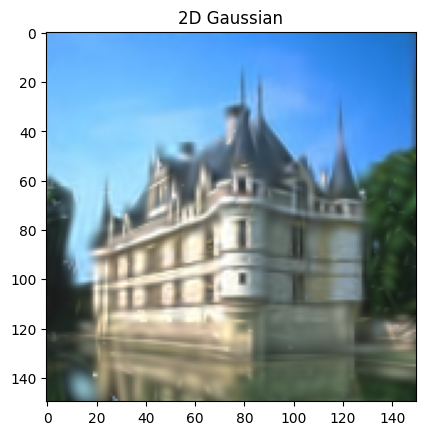

In [92]:
print(loss)
plot_image(w, 150, True)

torch.Size([3, 321, 321])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.11784986..1.0000002].


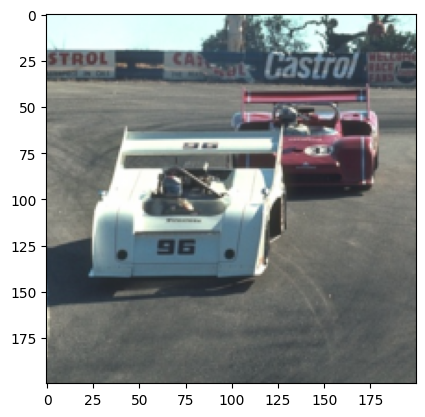

In [7]:

img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/bsd68-0005.png'), 0, 440-321, 321, 321).float()

print(img.size())

learning_rate = 0.01
iterations = 400
guassians = 2000

# create a 5x5 with a black stripe in the middle
output_z = torchvision.transforms.Resize(200)(img).to(device) / 255.0
plt.imshow(output_z.cpu().permute(1, 2, 0), origin='upper', vmin=0, vmax=1)



In [8]:
loss, w = train(learning_rate, iterations, guassians, output_z, True)

print(loss)

/var/home/victor/Code/bep/.venv/lib64/python3.13/site-packages/torch/nn/functional.py:5163: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


Iteration 40/400
Loss: 0.19217
Iteration 80/400
Loss: 0.11472
Iteration 120/400
Loss: 0.07495
Iteration 160/400
Loss: 0.05592
Iteration 200/400
Loss: 0.04610
Iteration 240/400
Loss: 0.04067
Iteration 280/400
Loss: 0.03745
Iteration 320/400
Loss: 0.03531
Iteration 360/400
Loss: 0.03355
Iteration 400/400
Loss: 0.03252
tensor(0.0325, device='cuda:0', grad_fn=<AddBackward0>)


tensor(0.0325, device='cuda:0', grad_fn=<AddBackward0>)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.09286245..2.286027].


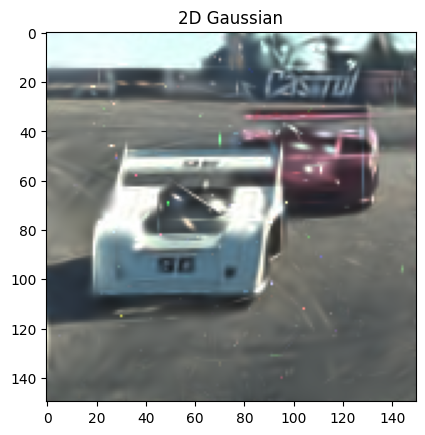

In [9]:
print(loss)
plot_image(w, 150, True)